In [1]:
import numpy as np
import pandas as pd # Operaciones con dataframes
from matplotlib import pyplot as plt # gráficos
from statsmodels.tsa.seasonal import seasonal_decompose # descomposición de series
from statsmodels.tsa.holtwinters import SimpleExpSmoothing  # Holwinters simple
from statsmodels.tsa.holtwinters import ExponentialSmoothing # Holwinters doble y tripe
from statsmodels.tsa.exponential_smoothing.ets import ETSModel
from sklearn.metrics import mean_squared_error

In [2]:
data = pd.read_excel("https://raw.githubusercontent.com/dagudelo30/Series-de-tiempo---Javeriana-Cali/main/intro-moving_average/datosEmpleo.xlsx",index_col='mes',parse_dates=True)
data.head()

,TD_13ciudades,Ocupados,Desocupados,Inactivos
mes,,,,
2001-01-01,20.946380,6923.604,1834.507,4600.718
2001-02-01,19.894213,7037.746,1747.820,4596.805
2001-03-01,19.221565,6945.973,1652.823,4807.120
2001-04-01,17.888575,6973.079,1519.137,4937.280
2001-05-01,17.945654,6994.462,1529.720,4928.911


(222, 4)


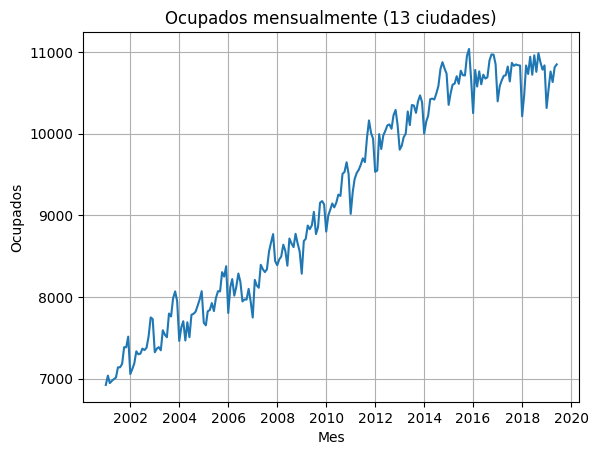

In [3]:
# imprimiendo el tamano del dataframe
print(data.shape)

# Graficando los datos
plt.title("Ocupados mensualmente (13 ciudades)")
plt.xlabel("Mes")
plt.ylabel("Ocupados")
plt.plot(data[["Ocupados"]])
plt.grid()
plt.show()

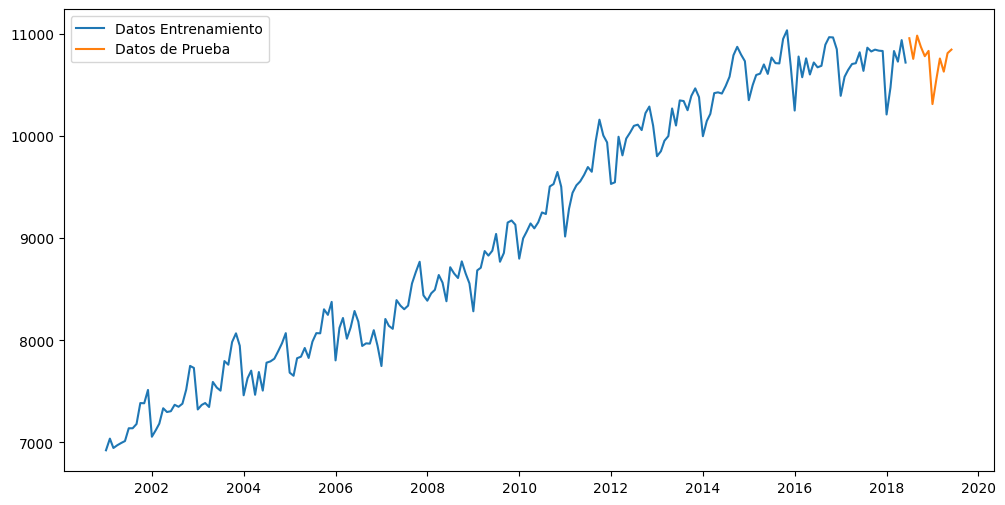

In [4]:
train_len = 210
train_td = data[["Ocupados"]][:train_len]
test_td = data[["Ocupados"]][train_len:]

fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(test_td,label="Datos de Prueba")
plt.legend()
plt.show()

In [5]:
train_td


,Ocupados
mes,
2001-01-01,6923.604
2001-02-01,7037.746
2001-03-01,6945.973
2001-04-01,6973.079
2001-05-01,6994.462
...,...
2018-02-01,10476.311
2018-03-01,10833.980
2018-04-01,10729.977


In [6]:
test_td

,Ocupados
mes,
2018-07-01,10959.197
2018-08-01,10756.782
2018-09-01,10984.928
2018-10-01,10874.338
2018-11-01,10783.299
2018-12-01,10835.398
2019-01-01,10314.438
2019-02-01,10557.917
2019-03-01,10760.776


# Suavizacion Exponencial Simple

In [10]:
# Build model.
ets_model = ETSModel(endog=train_td["Ocupados"],error="add")#,trend="add",seasonal="mul" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(12)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean

preds = pd.concat([limits, conf_forecast], axis = 1)
preds.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds)

            Point_forecast      lower_95      upper_95
2018-07-01    10771.208057  10414.447930  11127.968183
2018-08-01    10771.208057  10346.412706  11196.003408
2018-09-01    10771.208057  10287.860985  11254.555129
2018-10-01    10771.208057  10235.673096  11306.743018
2018-11-01    10771.208057  10188.137738  11354.278375
2018-12-01    10771.208057  10144.195857  11398.220257
2019-01-01    10771.208057  10103.138000  11439.278114
2019-02-01    10771.208057  10064.461353  11477.954760
2019-03-01    10771.208057  10027.794171  11514.621942
2019-04-01    10771.208057   9992.852414  11549.563700
2019-05-01    10771.208057   9959.413249  11583.002864
2019-06-01    10771.208057   9927.298043  11615.118071


/Users/juan/Documents/Universidad/2026-1/Series de Tiempo/suavizacion_exponencial/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


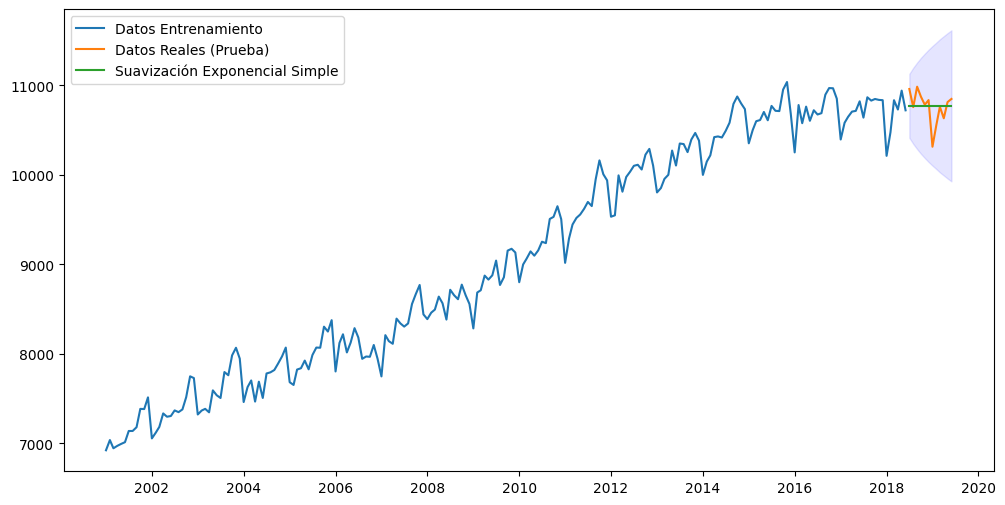

In [12]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td, label="Datos Entrenamiento")
plt.plot(test_td, label="Datos Reales (Prueba)")
plt.plot(preds['Point_forecast'], label="Suavización Exponencial Simple")
plt.fill_between(preds.index, preds['lower_95'], preds['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [22]:
print(ets_result.alpha)

0.6050130041156492


In [14]:
rmse = np.sqrt(mean_squared_error(test_td,point_forecast ))
print(rmse)

177.33723468884614


# Suavizacion Exponencial Lineal (Holt)

In [7]:
# Build model.
ets_model = ETSModel(endog=train_td["Ocupados"],error="mul",trend="mul")#,seasonal="mul" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(12)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_holt = pd.concat([limits, conf_forecast], axis = 1)
preds_holt.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_holt)

            Point_forecast      lower_95      upper_95
2018-07-01    10815.324563  10415.428123  11253.281284
2018-08-01    10839.229777  10340.916754  11288.602660
2018-09-01    10863.187829  10299.353147  11397.686963
2018-10-01    10887.198835  10291.849912  11451.750633
2018-11-01    10911.262913  10298.561001  11535.517275
2018-12-01    10935.380180  10285.582720  11629.709142
2019-01-01    10959.550754  10252.996363  11701.157056
2019-02-01    10983.774752  10287.556135  11740.090578
2019-03-01    11008.052293  10243.583523  11814.680929
2019-04-01    11032.383494  10234.917053  11926.463823
2019-05-01    11056.768476  10195.693175  12001.683494
2019-06-01    11081.207355  10187.609343  12023.952485


/Users/juan/Documents/Universidad/2026-1/Series de Tiempo/suavizacion_exponencial/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


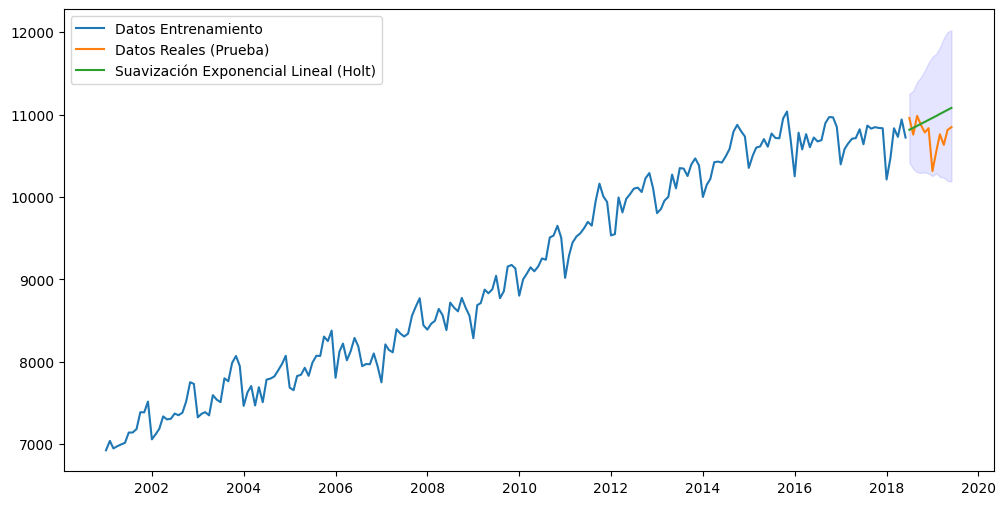

In [9]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td, label="Datos Entrenamiento")
plt.plot(test_td, label="Datos Reales (Prueba)")  # ← add this
plt.plot(preds_holt['Point_forecast'], label="Suavización Exponencial Lineal (Holt)")
plt.fill_between(preds_holt.index, preds_holt['lower_95'], preds_holt['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [10]:
print(ets_result.alpha,ets_result.beta)

0.5577172346968182 5.5771723469681825e-05


In [11]:
rmse_holt = np.sqrt(mean_squared_error(test_td,preds_holt['Point_forecast']))
print(rmse_holt)

288.9086217961285


# Suavizacion Exponencial Lineal de Winters (Holt-Winters)

In [12]:
# Build model
ets_model = ETSModel(endog=train_td["Ocupados"],error="add",trend="add",seasonal="add" )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(12)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_hw_add = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_add.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_add)

            Point_forecast      lower_95      upper_95
2018-07-01    10829.479191  10572.757472  11086.200910
2018-08-01    10934.593083  10663.276917  11205.909248
2018-09-01    10990.401503  10705.234144  11275.568863
2018-10-01    11089.307291  10790.928461  11387.686121
2018-11-01    11107.642417  10796.610312  11418.674523
2018-12-01    11003.713887  10680.521132  11326.906642
2019-01-01    10519.980439  10185.065995  10854.894884
2019-02-01    10796.947305  10450.705547  11143.189063
2019-03-01    10945.570209  10588.357993  11302.782425
2019-04-01    10957.466886  10589.609140  11325.324632
2019-05-01    11043.790411  10665.584622  11421.996199
2019-06-01    10999.068214  10610.788086  11387.348342


/Users/juan/Documents/Universidad/2026-1/Series de Tiempo/suavizacion_exponencial/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


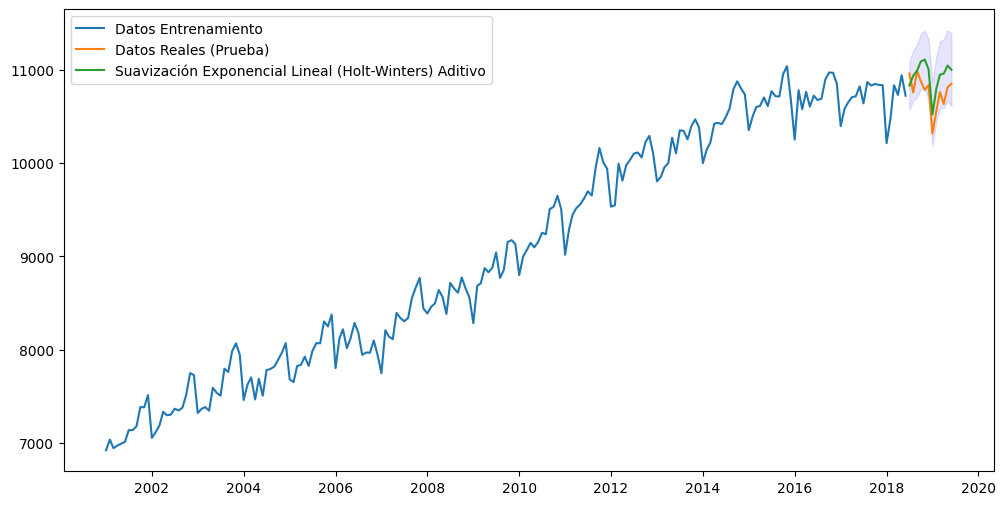

In [13]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(test_td, label="Datos Reales (Prueba)")
plt.plot(preds_hw_add['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) Aditivo")
plt.fill_between(preds_hw_add.index ,preds_hw_add['lower_95'], preds_hw_add['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [14]:
print(ets_result.alpha,ets_result.beta,ets_result.gamma)

0.3419166982488657 3.4191669824886575e-05 0.31488494862741806


In [15]:
rmse_hw_add = np.sqrt(mean_squared_error(test_td,preds_hw_add['Point_forecast']))
print(rmse_hw_add)

212.86586245114933


# Suavización Exponencial Lineal (Holt-Winters) Multiplicativo

In [16]:
# Build model.
ets_model = ETSModel(endog=train_td["Ocupados"],error="add",trend=None,seasonal="mul" , )
ets_result = ets_model.fit()

point_forecast=ets_result.forecast(12)

ci = ets_result.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_hw_mul = pd.concat([limits, conf_forecast], axis = 1)
preds_hw_mul.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_hw_mul)

            Point_forecast      lower_95      upper_95
2018-07-01    10846.757336  10606.391540  11070.188111
2018-08-01    10831.087951  10557.703596  11078.229983
2018-09-01    10893.100661  10592.101191  11196.453485
2018-10-01    11036.428727  10710.987902  11375.057750
2018-11-01    11051.205176  10682.835368  11405.256639
2018-12-01    10924.837117  10561.214992  11296.425432
2019-01-01    10448.091291  10033.661301  10829.203404
2019-02-01    10651.796795  10223.492497  11045.085307
2019-03-01    10735.511782  10269.057348  11181.701703
2019-04-01    10744.414253  10237.998317  11196.302437
2019-05-01    10813.080913  10310.070420  11260.469526
2019-06-01    10767.773012  10256.087360  11252.527330


/Users/juan/Documents/Universidad/2026-1/Series de Tiempo/suavizacion_exponencial/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


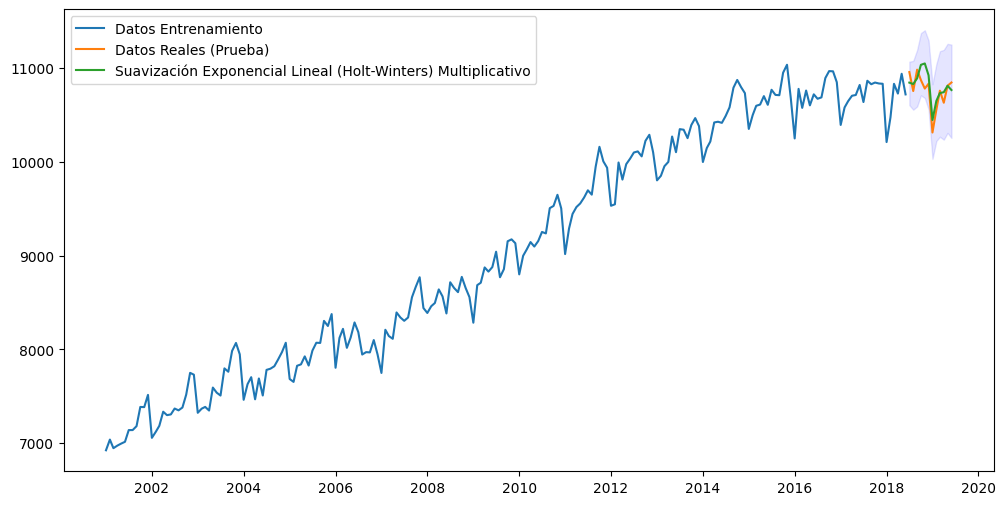

In [17]:
fig = plt.figure(figsize=(12, 6))
plt.plot(train_td,label="Datos Entrenamiento")
plt.plot(test_td, label="Datos Reales (Prueba)")
plt.plot(preds_hw_mul['Point_forecast'],label="Suavización Exponencial Lineal (Holt-Winters) Multiplicativo")
plt.fill_between(preds_hw_mul.index ,preds_hw_mul['lower_95'], preds_hw_mul['upper_95'], color='blue', alpha=0.1)
plt.legend()
plt.show()

In [19]:
print(ets_result.alpha,ets_result.gamma)

0.6050130041156492 3.949869958843508e-05


In [23]:
rmse_hw_mul = np.sqrt(mean_squared_error(test_td,preds_hw_mul['Point_forecast']))
print(rmse_hw_mul)

122.14224472568883


# Pronosticando con todo el data set

In [35]:
final_model = ETSModel(endog=data["Ocupados"],error="add",trend=None,seasonal="mul")
final_model_fit = final_model.fit_constrained({'smoothing_level': 0.6050130041156492,'smoothing_seasonal':3.949869958843508e-05})

print(final_model_fit.alpha)
print(final_model_fit.gamma)


0.6050130041156492
3.949869958843508e-05


/Users/juan/Documents/Universidad/2026-1/Series de Tiempo/suavizacion_exponencial/.venv/lib/python3.14/site-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency MS will be used.
  self._init_dates(dates, freq)


In [36]:
point_forecast=final_model_fit.forecast(6)

ci = final_model_fit.get_prediction(start = point_forecast.index[0],
                                end = point_forecast.index[-1])

conf_forecast = ci.pred_int(alpha=0.05)#.iloc[:,0]
limits = ci.predicted_mean


preds_final= pd.concat([limits, conf_forecast], axis = 1)
preds_final.columns = ['Point_forecast', 'lower_95', 'upper_95']
print(preds_final)


            Point_forecast      lower_95      upper_95
2019-07-01    10891.595351  10680.049165  11117.655485
2019-08-01    10861.211991  10620.239881  11127.441182
2019-09-01    10936.086372  10617.481516  11250.852159
2019-10-01    11060.132938  10722.572800  11393.159917
2019-11-01    11066.906519  10729.462353  11442.577476
2019-12-01    10953.370422  10593.816802  11327.850285


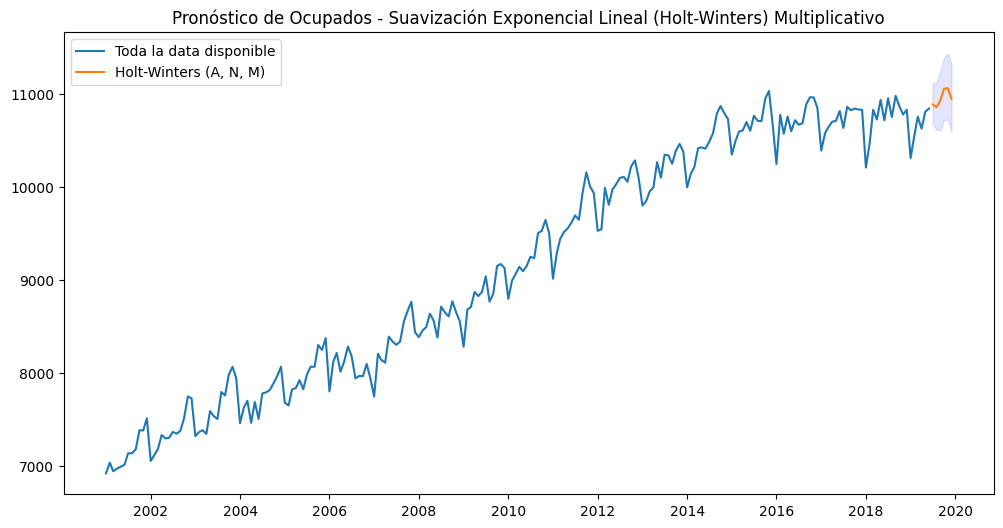

In [38]:
fig = plt.figure(figsize=(12, 6))
plt.plot(data["Ocupados"],label="Toda la data disponible")
plt.plot(preds_final['Point_forecast'],label="Holt-Winters (A, N, M)")
plt.fill_between(preds_final.index ,preds_final['lower_95'], preds_final['upper_95'], color='blue', alpha=0.1)
plt.title("Pronóstico de Ocupados - Suavización Exponencial Lineal (Holt-Winters) Multiplicativo")
plt.legend()
plt.show()


# Justificación Técnica: Selección del Modelo ETS(A, N, M)

El modelo seleccionado es **ETS(A, N, M)** — Error Aditivo, Sin Tendencia, Estacionalidad Multiplicativa.

---

## 1. Sin Componente de Tendencia (N)

Los datos de ocupación en una economía establecida tienden a oscilar alrededor de un **nivel estable a largo plazo**, en lugar de crecer o decrecer indefinidamente. Esto se sustenta en:

- **β ≈ 0** en ambos modelos de Holt (`5.57e-05` y `3.41e-05`) — cuando el optimizador tiene libertad para estimar una tendencia, la fija esencialmente en cero, lo cual es evidencia estadística sólida de que no existe una tendencia significativa en la ventana de entrenamiento.
- Incluir una tendencia cuando β ≈ 0 agrega un parámetro sin mejorar el ajuste, violando el **principio de parsimonia**.
- Ambos modelos que incluyeron tendencia (Holt y Holt-Winters Aditivo) presentaron **mayor RMSE** que el modelo sin tendencia, confirmando que la tendencia agrega ruido en lugar de señal.

---

## 2. Estacionalidad Multiplicativa (M)

El empleo es inherentemente estacional — fluctúa de manera predecible a lo largo del año debido a:

- Calendarios académicos (egresados ingresando al mercado laboral)
- Temporadas de festividades (contratación en comercio y turismo)
- Ciclos agrícolas

**Estacionalidad Multiplicativa vs. Aditiva:**

La distinción clave radica en cómo escalan las fluctuaciones estacionales con el nivel de la serie:

- **Aditiva (A):** la desviación estacional es constante en términos absolutos → la misma variación ±X trabajadores cada año, independientemente del nivel de empleo.
- **Multiplicativa (M):** la desviación estacional es proporcional al nivel → si el empleo aumenta, las oscilaciones estacionales también aumentan proporcionalmente.

Para datos de ocupación, la estacionalidad multiplicativa es más realista porque una variación estacional del 5% sobre 1.000.000 de trabajadores produce una fluctuación absoluta mayor que sobre 800.000 trabajadores. Esto se confirma empíricamente:

| Modelo | Estacionalidad | RMSE |
|---|---|---|
| Holt-Winters | Aditiva | 212.87 |
| Holt-Winters | **Multiplicativa** | **122.14** |

El modelo multiplicativo reduce el RMSE en **~90.000 trabajadores (~42% de mejora)** frente a la versión aditiva — una ganancia sustancial y significativa.

---

## 3. Error Aditivo (A)

La estructura de error aditivo asume que los **residuos tienen varianza constante** (homocedasticidad) — es decir, los errores de pronóstico no escalan con el nivel de la serie. Esto es apropiado cuando:

- La serie no exhibe volatilidad que crezca exponencialmente.
- Los valores de ocupación se mantienen dentro de un rango acotado, como se espera en una economía estable.

Un error multiplicativo (como el utilizado en el modelo Holt) implicaría que los errores crecen proporcionalmente al nivel, lo cual es más típico de datos financieros o de ventas con crecimiento explosivo — no de datos de empleo.

---

## 4. Interpretación de los Parámetros

```
α = 0.605   (suavización del nivel)
γ = 0.00004 (suavización estacional)
```

- **α = 0.605** — el nivel se adapta a una velocidad moderada a las observaciones recientes. Esto tiene sentido para el empleo, que puede cambiar de manera significativa mes a mes debido a eventos económicos, sin llegar a depender casi exclusivamente del dato más reciente (α → 1).

- **γ ≈ 0** — el patrón estacional es **extremadamente estable en el tiempo**. Esto es económicamente razonable: la estructura estacional del empleo está determinada por factores estructurales como calendarios académicos y festividades, los cuales cambian muy lentamente a lo largo de los años, no de los meses.

---

## 5. Comparación de RMSE

| Modelo | RMSE | vs. Ganador |
|---|---|---|
| ETS(A,N,N) Simple | 177.34 | +45% peor |
| ETS(M,M,N) Holt | 288.91 | +136% peor |
| ETS(A,A,A) HW Aditivo | 212.87 | +74% peor |
| **ETS(A,N,M) HW Multiplicativo** | **122.14** | — |

Un RMSE de **122.140 trabajadores** en una serie que probablemente oscila en el orden de los millones representa un pronóstico sólido, y ningún modelo competidor se aproxima a este resultado.

---

## Conclusión

**ETS(A, N, M)** es el modelo óptimo porque:

1. Los datos **no muestran una tendencia estadísticamente significativa** (β → 0 en todos los modelos con tendencia).
2. La **estacionalidad multiplicativa** captura correctamente cómo las fluctuaciones del empleo escalan con el nivel de la serie.
3. Los **errores aditivos** son apropiados para una serie acotada y no explosiva.
4. Alcanza el **menor RMSE por un amplio margen**, siendo al mismo tiempo el modelo más parsimonioso entre los que incluyen estacionalidad.